# Proyecto de Consultoría ante Hackeo
## Laboratorio 12

In [63]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, year, count, when, isnan, corr, max as spark_max, min as spark_min, mean
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

## Corrección de errores para spark

In [5]:
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!wget -q https://archive.apache.org/dist/spark/spark-3.5.0/spark-3.5.0-bin-hadoop3.tgz
!tar xf spark-3.5.0-bin-hadoop3.tgz
!pip install -q findspark

E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?
^C

gzip: stdin: unexpected end of file
tar: Unexpected EOF in archive
tar: Unexpected EOF in archive
tar: Error is not recoverable: exiting now


In [6]:
import os

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.0-bin-hadoop3"

## Iniciar sesión de Spark

In [65]:
import findspark
findspark.init()

spark = SparkSession.builder \
    .appName("Lab Spark Hacking") \
    .config("spark.ui.showConsoleProgress", "false") \
    .getOrCreate()

print("Spark session iniciada correctamente")
print("Spark version:", spark.version)

Spark session iniciada correctamente
Spark version: 3.5.0


## Cargar los datos

In [66]:
df_hack = spark.read.csv(
    'hack_data.csv',
    header=True,
    inferSchema=True
)

## **Análisis de datos**

In [67]:
# Contar registros
total_registros = df_hack.count()
print(f"Total de datos en el dataset: {total_registros}")

Total de datos en el dataset: 334


In [68]:
df_hack.printSchema()

root
 |-- Session_Connection_Time: double (nullable = true)
 |-- Bytes Transferred: double (nullable = true)
 |-- Kali_Trace_Used: integer (nullable = true)
 |-- Servers_Corrupted: double (nullable = true)
 |-- Pages_Corrupted: double (nullable = true)
 |-- Location: string (nullable = true)
 |-- WPM_Typing_Speed: double (nullable = true)



In [69]:
df_hack.describe().show()

+-------+-----------------------+------------------+------------------+-----------------+------------------+-----------+------------------+
|summary|Session_Connection_Time| Bytes Transferred|   Kali_Trace_Used|Servers_Corrupted|   Pages_Corrupted|   Location|  WPM_Typing_Speed|
+-------+-----------------------+------------------+------------------+-----------------+------------------+-----------+------------------+
|  count|                    334|               334|               334|              334|               334|        334|               334|
|   mean|     30.008982035928145| 607.2452694610777|0.5119760479041916|5.258502994011977|10.838323353293413|       NULL|57.342395209580864|
| stddev|     14.088200614636158|286.33593163576757|0.5006065264451406| 2.30190693339697|  3.06352633036022|       NULL| 13.41106336843464|
|    min|                    1.0|              10.0|                 0|              1.0|               6.0|Afghanistan|              40.0|
|    max|           

In [70]:
# Verificar valores nulos
print("Análisis de Valores Nulos:")
df_hack.select([count(when(col(c).isNull() | isnan(c), c)).alias(c)
                   for c in df_hack.columns]).show()

Análisis de Valores Nulos:
+-----------------------+-----------------+---------------+-----------------+---------------+--------+----------------+
|Session_Connection_Time|Bytes Transferred|Kali_Trace_Used|Servers_Corrupted|Pages_Corrupted|Location|WPM_Typing_Speed|
+-----------------------+-----------------+---------------+-----------------+---------------+--------+----------------+
|                      0|                0|              0|                0|              0|       0|               0|
+-----------------------+-----------------+---------------+-----------------+---------------+--------+----------------+



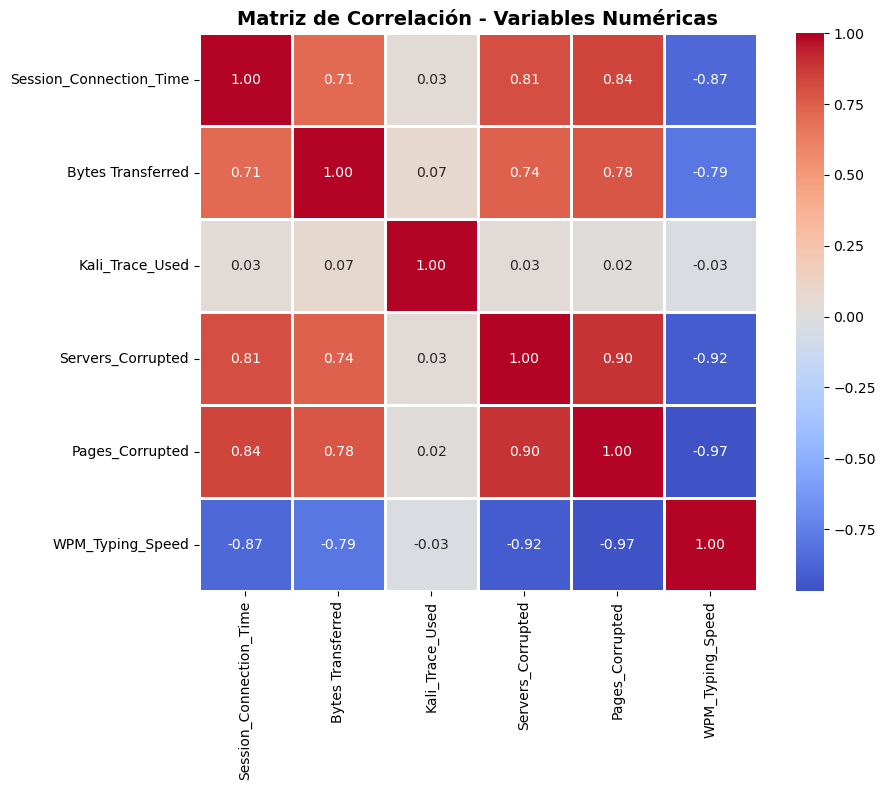

In [71]:
# Seleccionar solo variables a usar por el momento
# Debido al uso de VPNs Location no es una variable que aporte información relevante
toUse_cols = ["Session_Connection_Time","Bytes Transferred","Kali_Trace_Used","Servers_Corrupted","Pages_Corrupted","WPM_Typing_Speed"]

# Convertir a Pandas para análisis de correlación más fácil
df_pandas = df_hack.select(toUse_cols).toPandas()

# Matriz de correlación
correlation_matrix = df_pandas.corr()

# Heatmap de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Matriz de Correlación - Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()

In [72]:
# Identificar multicolinealidad (correlaciones altas entre predictores)
print("Análisis de Multicolinealidad:")
print("Pares de variables con correlación > 0.9:")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:
            print(f"  - {correlation_matrix.columns[i]} vs {correlation_matrix.columns[j]}: "
                  f"{correlation_matrix.iloc[i, j]:.3f}")

Análisis de Multicolinealidad:
Pares de variables con correlación > 0.9:
  - Servers_Corrupted vs WPM_Typing_Speed: -0.916
  - Pages_Corrupted vs WPM_Typing_Speed: -0.969


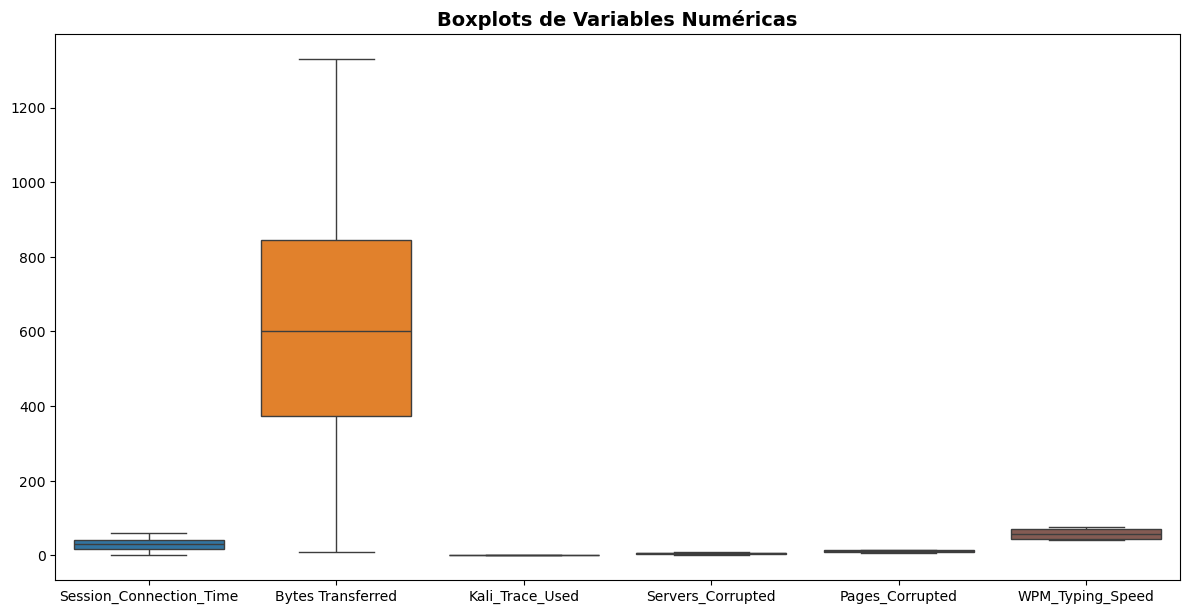

In [73]:
# Verificación de outliers
plt.figure(figsize=(12, 6))  # ajusta ancho x alto
sns.boxplot(data=df_pandas)
plt.tight_layout()
plt.title('Boxplots de Variables Numéricas', fontsize=14, fontweight='bold')
plt.show()

## preprocesamiento

In [74]:
from sklearn.preprocessing import StandardScaler
scaled = StandardScaler().fit_transform(df_pandas.drop(columns=['WPM_Typing_Speed']))

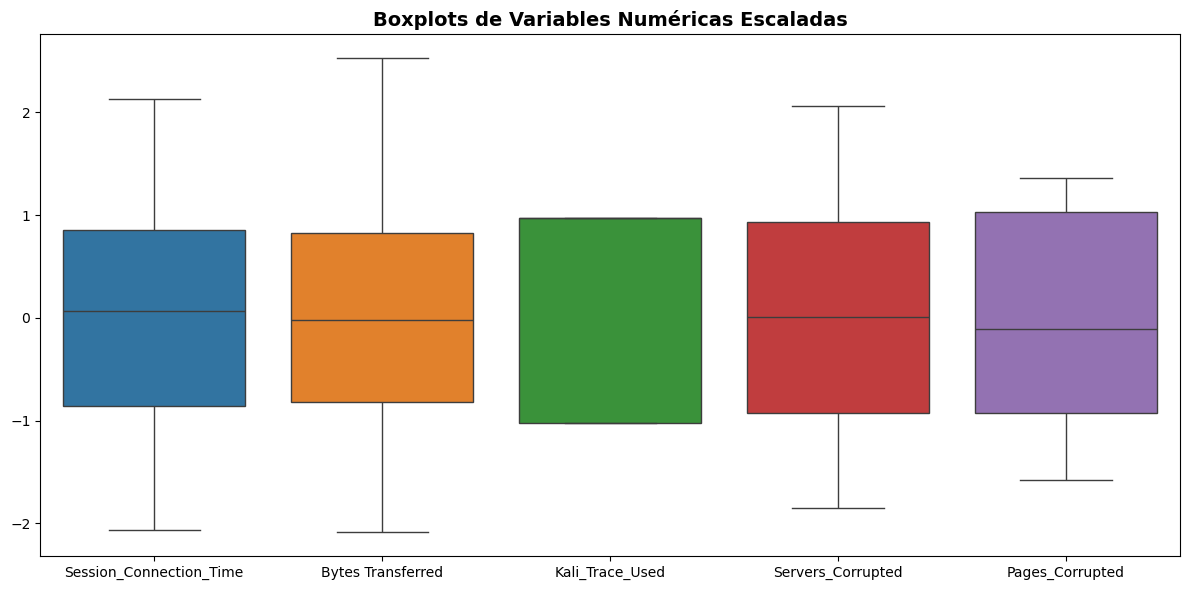

In [75]:
df_scaled = pd.DataFrame(
    scaled,
    columns=df_pandas.drop(columns=['WPM_Typing_Speed']).columns
)

# visualización de datos escalados
plt.figure(figsize=(12,6))
sns.boxplot(data=df_scaled)
plt.title('Boxplots de Variables Numéricas Escaladas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [76]:
# Convertir el df procesado de pandas a spark
df = spark.createDataFrame(df_scaled)

In [77]:
# Describir variables escaladas
df.describe().show()

+-------+-----------------------+--------------------+--------------------+--------------------+--------------------+
|summary|Session_Connection_Time|   Bytes Transferred|     Kali_Trace_Used|   Servers_Corrupted|     Pages_Corrupted|
+-------+-----------------------+--------------------+--------------------+--------------------+--------------------+
|  count|                    334|                 334|                 334|                 334|                 334|
|   mean|   -2.55284815243149...|-1.48916142225170...|1.861451777814633...|-5.10569630486299...|-4.25474692071916...|
| stddev|     1.0015003759375245|  1.0015003759375247|  1.0015003759375247|  1.0015003759375245|  1.0015003759375245|
|    min|    -2.0621871599673574|  -2.088949711882618|   -1.02424594439091| -1.8527648913851973| -1.5817009990121091|
|    max|     2.1319980164509253|   2.529685605279595|   0.976328005472037|  2.0629031370073827|   1.360497765239376|
+-------+-----------------------+--------------------+--

## **Clustering**

In [78]:
# lista de variables usadas
feature_cols = df_scaled.columns

### 1. Preparación de Features para Spark ML

In [79]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

# Ensamblar features en un solo vector
assembler = VectorAssembler(
    inputCols=feature_cols.tolist(),
    outputCol="features"
)

df_features = assembler.transform(df)

print("✓ Features ensambladas correctamente")
df_features.select("features").show(5, truncate=False)

✓ Features ensambladas correctamente
+---------------------------------------------------------------------------------------------------+
|features                                                                                           |
+---------------------------------------------------------------------------------------------------+
|[-1.5645719695448492,-0.7560335944897003,0.976328005472037,-1.0000194096463688,-1.2547900252063886]|
|[-0.7115173573919781,0.3978382655116736,-1.02424594439091,-0.9652134716162125,-0.6009680775949474] |
|[0.07044937041482031,-0.8776465819775686,0.976328005472037,-0.6737137406136539,-0.927879051400668] |
|[-1.9910992756212846,-1.3261841003970174,0.976328005472037,-1.2088550378273064,-0.927879051400668] |
|[-0.7115173573919781,-0.695139659713635,-1.02424594439091,-0.7346241321664273,-0.927879051400668]  |
+---------------------------------------------------------------------------------------------------+
only showing top 5 rows



### 2. Método del Codo para determinar K óptimo

In [93]:
# Evaluar diferentes valores de K
wssse_values = []
silhouette_scores = []
K_range = range(2, 8)

print("Evaluando diferentes valores de K...")
for k in K_range:
    # Entrenar modelo
    kmeans = KMeans(k=k, seed=42, maxIter=100)
    model = kmeans.fit(df_features)
    
    # WSSSE (Within Set Sum of Squared Errors)
    wssse = model.summary.trainingCost
    wssse_values.append(wssse)
    
    # Silhouette Score
    predictions = model.transform(df_features)
    evaluator = ClusteringEvaluator(featuresCol="features", 
                                     predictionCol="prediction",
                                     metricName="silhouette")
    silhouette = evaluator.evaluate(predictions)
    silhouette_scores.append(silhouette)
    
    print(f"K={k} → WSSSE: {wssse:.2f}, Silhouette: {silhouette:.4f}")


Evaluando diferentes valores de K...
K=2 → WSSSE: 598.59, Silhouette: 0.7725
K=3 → WSSSE: 431.13, Silhouette: 0.7327
K=4 → WSSSE: 263.10, Silhouette: 0.7234
K=5 → WSSSE: 241.27, Silhouette: 0.6403
K=6 → WSSSE: 230.22, Silhouette: 0.6324
K=7 → WSSSE: 214.36, Silhouette: 0.5616


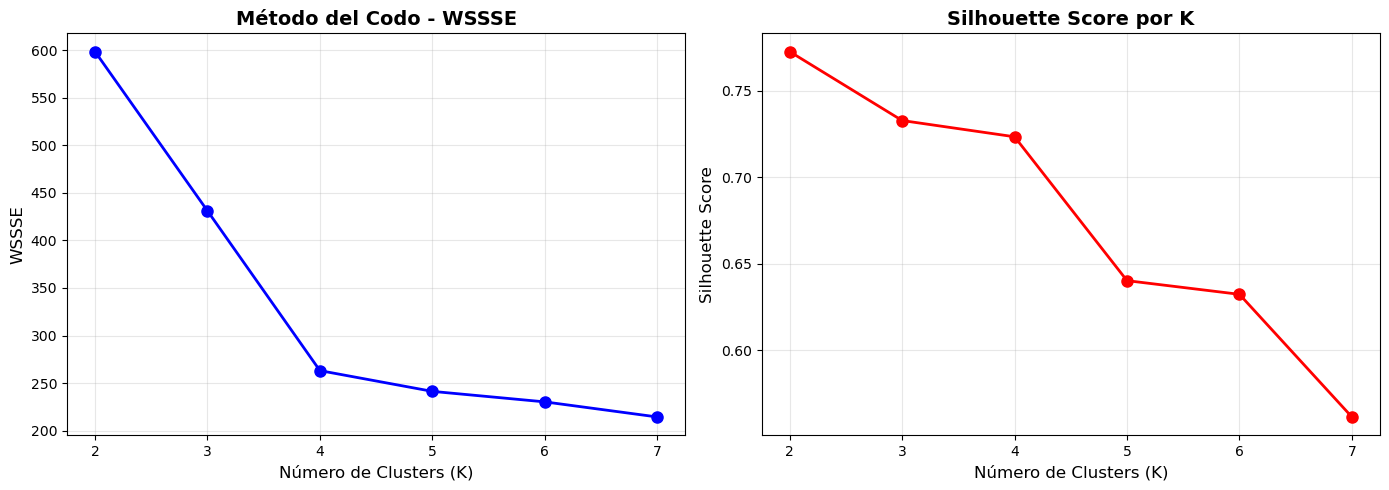

In [94]:
# Visualizar Método del Codo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# WSSSE
axes[0].plot(list(K_range), wssse_values, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (K)', fontsize=12)
axes[0].set_ylabel('WSSSE', fontsize=12)
axes[0].set_title('Método del Codo - WSSSE', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette Score
axes[1].plot(list(K_range), silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score por K', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Entrenar modelos con K=2 y K=3

In [95]:
# Modelo con 2 clusters (hipótesis: 2 hackers)
print("MODELO CON K=2 (Hipótesis: 2 hackers)")

kmeans_2 = KMeans(k=2, seed=42, maxIter=100)
model_2 = kmeans_2.fit(df_features)
predictions_2 = model_2.transform(df_features)

# Métricas K=2
wssse_2 = model_2.summary.trainingCost
evaluator = ClusteringEvaluator(featuresCol="features", predictionCol="prediction")
silhouette_2 = evaluator.evaluate(predictions_2)

print(f"WSSSE: {wssse_2:.2f}")
print(f"Silhouette Score: {silhouette_2:.4f}")


MODELO CON K=2 (Hipótesis: 2 hackers)
WSSSE: 598.59
Silhouette Score: 0.7725


In [96]:
# Modelo con 3 clusters (hipótesis: 3 hackers)
print("MODELO CON K=3 (Hipótesis: 3 hackers)")

kmeans_3 = KMeans(k=3, seed=42, maxIter=100)
model_3 = kmeans_3.fit(df_features)
predictions_3 = model_3.transform(df_features)

# Métricas K=3
wssse_3 = model_3.summary.trainingCost
silhouette_3 = evaluator.evaluate(predictions_3)

print(f"WSSSE: {wssse_3:.2f}")
print(f"Silhouette Score: {silhouette_3:.4f}")

MODELO CON K=3 (Hipótesis: 3 hackers)
WSSSE: 431.13
Silhouette Score: 0.7327


### 4. Análisis de Distribución de Ataques

In [97]:
# Distribución con K=2
print("DISTRIBUCIÓN DE ATAQUES - K=2")

dist_2 = predictions_2.groupBy("prediction").count().orderBy("prediction").toPandas()
total_attacks = dist_2['count'].sum()

print(dist_2)
print(f"\nTotal de ataques: {total_attacks}")
for idx, row in dist_2.iterrows():
    percentage = (row['count'] / total_attacks) * 100
    print(f"Cluster {row['prediction']}: {row['count']} ataques ({percentage:.1f}%)")

DISTRIBUCIÓN DE ATAQUES - K=2
   prediction  count
0           0    167
1           1    167

Total de ataques: 334
Cluster 0: 167 ataques (50.0%)
Cluster 1: 167 ataques (50.0%)


In [98]:
# Distribución con K=3
print("DISTRIBUCIÓN DE ATAQUES - K=3")

dist_3 = predictions_3.groupBy("prediction").count().orderBy("prediction").toPandas()

print(dist_3)
print(f"\nTotal de ataques: {total_attacks}")
for idx, row in dist_3.iterrows():
    percentage = (row['count'] / total_attacks) * 100
    print(f"Cluster {row['prediction']}: {row['count']} ataques ({percentage:.1f}%)")


DISTRIBUCIÓN DE ATAQUES - K=3
   prediction  count
0           0    167
1           1     88
2           2     79

Total de ataques: 334
Cluster 0: 167 ataques (50.0%)
Cluster 1: 88 ataques (26.3%)
Cluster 2: 79 ataques (23.7%)


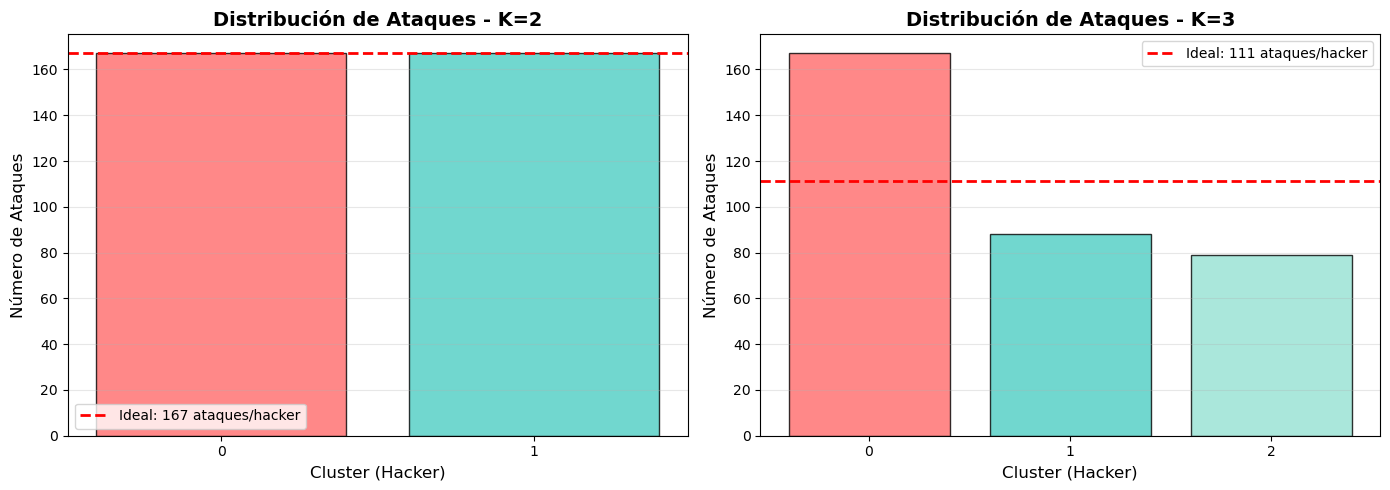

In [99]:
# Visualizar distribuciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K=2
axes[0].bar(dist_2['prediction'].astype(str), dist_2['count'], 
            color=['#FF6B6B', '#4ECDC4'], alpha=0.8, edgecolor='black')
axes[0].axhline(y=total_attacks/2, color='red', linestyle='--', linewidth=2, 
                label=f'Ideal: {total_attacks/2:.0f} ataques/hacker')
axes[0].set_xlabel('Cluster (Hacker)', fontsize=12)
axes[0].set_ylabel('Número de Ataques', fontsize=12)
axes[0].set_title('Distribución de Ataques - K=2', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# K=3
axes[1].bar(dist_3['prediction'].astype(str), dist_3['count'], 
            color=['#FF6B6B', '#4ECDC4', '#95E1D3'], alpha=0.8, edgecolor='black')
axes[1].axhline(y=total_attacks/3, color='red', linestyle='--', linewidth=2,
                label=f'Ideal: {total_attacks/3:.0f} ataques/hacker')
axes[1].set_xlabel('Cluster (Hacker)', fontsize=12)
axes[1].set_ylabel('Número de Ataques', fontsize=12)
axes[1].set_title('Distribución de Ataques - K=3', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 5. Análisis de Características por Cluster

In [100]:
# Convertir predicciones a Pandas para análisis detallado
pred_2_pd = predictions_2.select(feature_cols.tolist() + ["prediction"]).toPandas()
pred_3_pd = predictions_3.select(feature_cols.tolist() + ["prediction"]).toPandas()

# Estadísticas por cluster K=2
print("CARACTERÍSTICAS PROMEDIO POR CLUSTER - K=2")
stats_k2 = pred_2_pd.groupby('prediction').mean()
print(stats_k2)

# Estadísticas por cluster K=3
print("CARACTERÍSTICAS PROMEDIO POR CLUSTER - K=3")
stats_k3 = pred_3_pd.groupby('prediction').mean()
print(stats_k3)

CARACTERÍSTICAS PROMEDIO POR CLUSTER - K=2
            Session_Connection_Time  Bytes Transferred  Kali_Trace_Used  \
prediction                                                                
0                         -0.871146           -0.80365        -0.029949   
1                          0.871146            0.80365         0.029949   

            Servers_Corrupted  Pages_Corrupted  
prediction                                      
0                   -0.920872        -0.976818  
1                    0.920872         0.976818  
CARACTERÍSTICAS PROMEDIO POR CLUSTER - K=3
            Session_Connection_Time  Bytes Transferred  Kali_Trace_Used  \
prediction                                                                
0                         -0.871146          -0.803650        -0.029949   
1                          0.927543           0.838056         0.976328   
2                          0.808324           0.765324        -1.024246   

            Servers_Corrupted  Pages_Corr

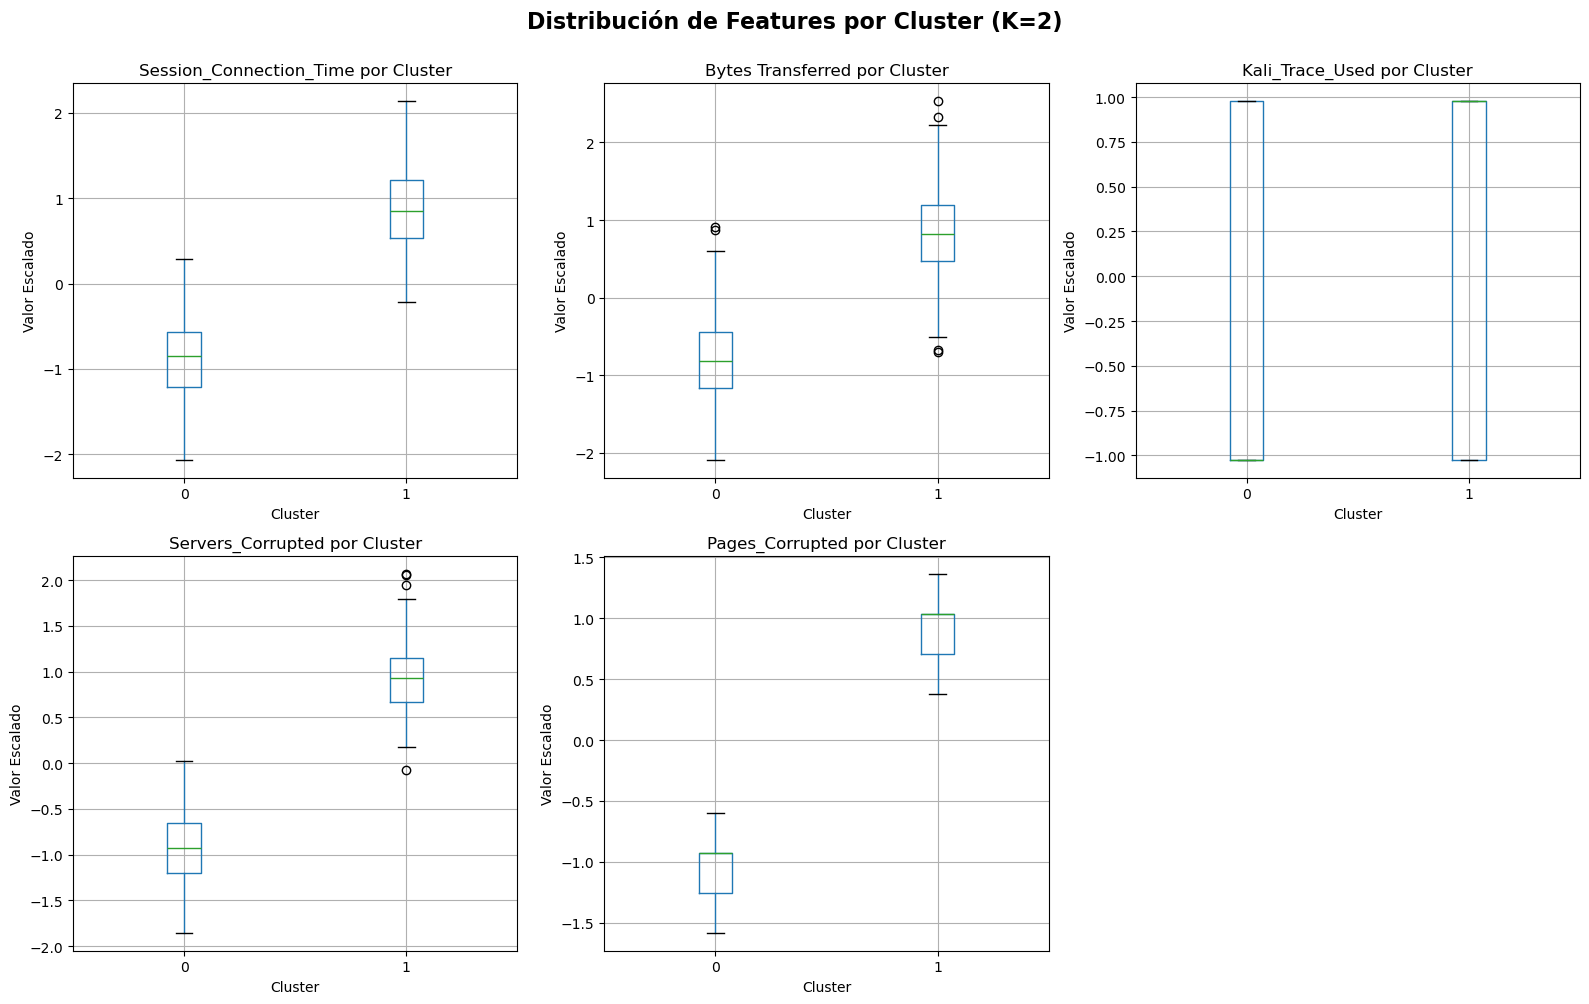

In [101]:
# Visualización de características por cluster (K=2)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(feature_cols):
    pred_2_pd.boxplot(column=col, by='prediction', ax=axes[idx])
    axes[idx].set_title(f'{col} por Cluster')
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel('Valor Escalado')

# Ocultar el subplot extra si hay uno
if len(feature_cols) < 6:
    for idx in range(len(feature_cols), 6):
        axes[idx].set_visible(False)

plt.suptitle('Distribución de Features por Cluster (K=2)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 6. Reducción Dimensional y Visualización

In [102]:
from sklearn.decomposition import PCA

# Aplicar PCA a los datos escalados
pca = PCA(n_components=2)
pca_features = pca.fit_transform(df_scaled)

print(f"Varianza explicada por los 2 componentes principales:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total: {sum(pca.explained_variance_ratio_):.2%}")


Varianza explicada por los 2 componentes principales:
PC1: 68.00%
PC2: 20.00%
Total: 88.00%


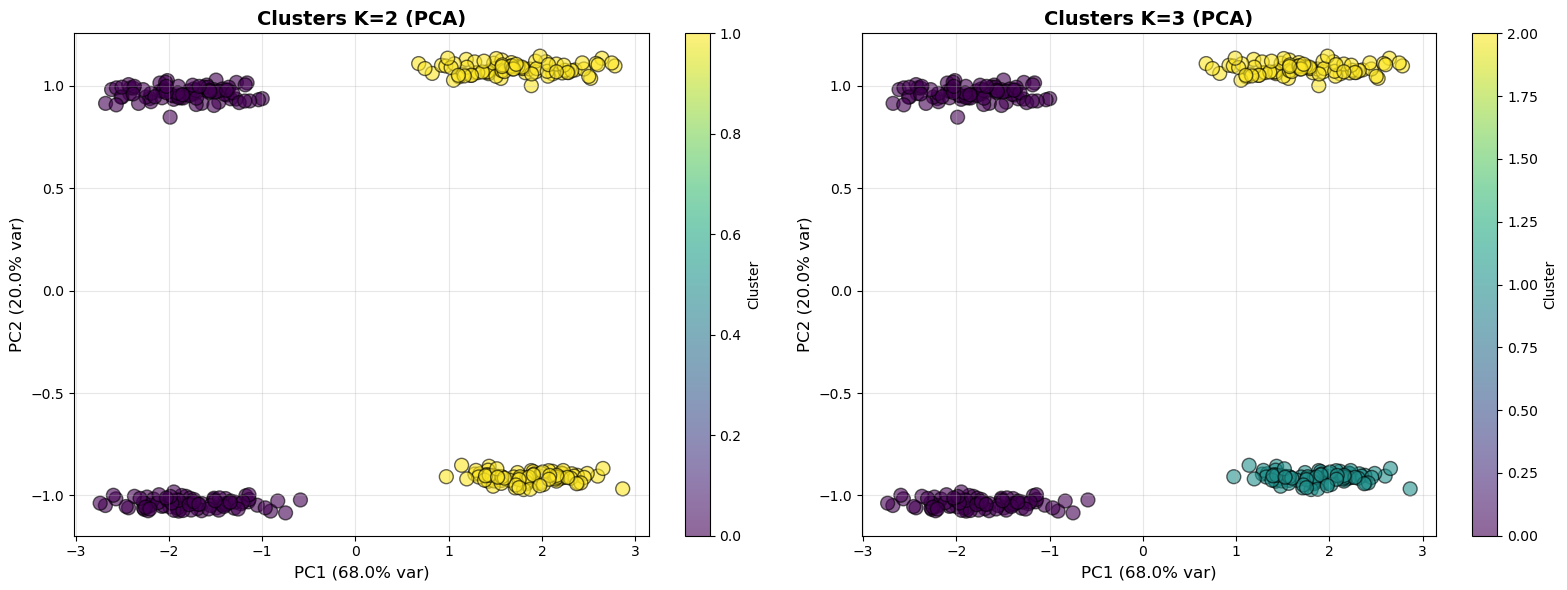

In [103]:
# Preparar datos para visualización
pca_df = pd.DataFrame(
    pca_features, 
    columns=['PC1', 'PC2']
)

pca_df['Cluster_K2'] = pred_2_pd['prediction']
pca_df['Cluster_K3'] = pred_3_pd['prediction']

# Visualización de clusters en espacio PCA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K=2
scatter1 = axes[0].scatter(pca_df['PC1'], pca_df['PC2'], 
                           c=pca_df['Cluster_K2'], 
                           cmap='viridis', 
                           s=100, alpha=0.6, edgecolors='black')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)', fontsize=12)
axes[0].set_title('Clusters K=2 (PCA)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# K=3
scatter2 = axes[1].scatter(pca_df['PC1'], pca_df['PC2'], 
                           c=pca_df['Cluster_K3'], 
                           cmap='viridis', 
                           s=100, alpha=0.6, edgecolors='black')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)', fontsize=12)
axes[1].set_title('Clusters K=3 (PCA)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

### 7. Evaluación y Recomendación Final

In [104]:
# Calcular desviación estándar de la distribución de ataques
std_k2 = dist_2['count'].std()
std_k3 = dist_3['count'].std()

# Calcular cuán cerca está cada cluster del ideal
ideal_k2 = total_attacks / 2
ideal_k3 = total_attacks / 3

deviation_k2 = [abs(count - ideal_k2) for count in dist_2['count']]
deviation_k3 = [abs(count - ideal_k3) for count in dist_3['count']]

mean_deviation_k2 = np.mean(deviation_k2)
mean_deviation_k3 = np.mean(deviation_k3)

# %%
# Resumen de métricas
print("RESUMEN COMPARATIVO DE MODELOS")

comparison_data = {
    'Métrica': [
        'WSSSE',
        'Silhouette Score',
        'Desv. Est. Distribución',
        'Desviación del Ideal',
        'Distribución más uniforme'
    ],
    'K=2 (2 hackers)': [
        f'{wssse_2:.2f}',
        f'{silhouette_2:.4f}',
        f'{std_k2:.2f}',
        f'{mean_deviation_k2:.2f}',
        'si' if std_k2 < std_k3 else 'no'
    ],
    'K=3 (3 hackers)': [
        f'{wssse_3:.2f}',
        f'{silhouette_3:.4f}',
        f'{std_k3:.2f}',
        f'{mean_deviation_k3:.2f}',
        'si' if std_k3 < std_k2 else 'no'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# %%
print("ANÁLISIS DE DISTRIBUCIÓN")
print("="*70)

print(f"\nK=2 (2 hackers):")
print(f"  - Distribución ideal: {ideal_k2:.0f} ataques por hacker")
print(f"  - Distribución real: {dist_2['count'].tolist()}")
print(f"  - Desviación promedio: {mean_deviation_k2:.2f} ataques")

print(f"\nK=3 (3 hackers):")
print(f"  - Distribución ideal: {ideal_k3:.0f} ataques por hacker")
print(f"  - Distribución real: {dist_3['count'].tolist()}")
print(f"  - Desviación promedio: {mean_deviation_k3:.2f} ataques")

RESUMEN COMPARATIVO DE MODELOS
                  Métrica K=2 (2 hackers) K=3 (3 hackers)
                    WSSSE          598.59          431.13
         Silhouette Score          0.7725          0.7327
  Desv. Est. Distribución            0.00           48.42
     Desviación del Ideal            0.00           37.11
Distribución más uniforme              si              no
ANÁLISIS DE DISTRIBUCIÓN

K=2 (2 hackers):
  - Distribución ideal: 167 ataques por hacker
  - Distribución real: [167, 167]
  - Desviación promedio: 0.00 ataques

K=3 (3 hackers):
  - Distribución ideal: 111 ataques por hacker
  - Distribución real: [167, 88, 79]
  - Desviación promedio: 37.11 ataques


### Cerrar sesión de Spark)

In [ ]:
spark.stop()